# DAF-04: Downloading Immutable OpenAQ Sensor History

Asha needs several years of Delhi PM2.5 history for forecasting.

The previous notebook used one cached API CSV. That helped us explore the data, but it is not a reproducible raw archive. If the API response changes later, we cannot prove exactly what data was used.

The OpenAQ S3 archive gives us the original daily files. We will download those files without modifying their contents.

This notebook will follow this order:

1. Understand the archive file layout.
2. Verify the reusable collector's command-line interface.
3. Download one station for one month.
4. Run the same command again to prove it is idempotent.
5. Inspect the downloaded raw file without editing it.
6. Only then consider the full date range.

## 1. Why we verify the command before downloading

The collector is a reusable Python module, not just notebook code.

Before downloading data, we want to confirm that:

- Python can find the `delhi_air` package.
- The module exposes a command-line interface.
- The date range is required.
- We can optionally select one station.
- The output directory can be controlled.

If this check fails, downloading data would only hide the real problem.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from delhi_air.collect_openaq import archive_url, load_station_ids

print("Project root:", project_root)
print("Source directory:", src_dir)
print("Collector import: successful")

Project root: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast
Source directory: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/src
Collector import: successful


## 2. Understanding one archive URL

The archive stores one compressed CSV file per station per day.

For example:

```text
locationid=301/year=2022/month=09/location-301-20220916.csv.gz

In [2]:
from datetime import date

example_location_id = 301
example_day = date(2022, 9, 16)

example_url = archive_url(example_location_id, example_day)

print(example_url)

https://openaq-data-archive.s3.amazonaws.com/records/csv.gz/locationid=301/year=2022/month=09/location-301-20220916.csv.gz


## 3. Verifying the reusable collector before downloading

The URL we just built is only the path to one raw file.

The real question now is whether the collector itself is usable as a command-line tool. We want to prove that:

- the package is importable from the project source
- the module exposes a CLI
- required arguments are enforced
- the output folder can be controlled

This matters because a download script is only reliable if its interface is clear and reproducible. If the CLI fails here, the real data download would only hide a deeper problem.

In [3]:
import os
import subprocess
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_dir = project_root / "src"

env = os.environ.copy()
env["PYTHONPATH"] = str(src_dir)

print("Project root:", project_root)
print("Source dir:", src_dir)

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "delhi_air.collect_openaq",
        "--help",
    ],
    cwd=project_root,
    env=env,
    capture_output=True,
    text=True,
)

print("\n--- CLI help output ---")
print(result.stdout)

if result.stderr:
    print("\n--- CLI error output ---")
    print(result.stderr)

print(f"\nExit code: {result.returncode}")

Project root: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast
Source dir: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/src

--- CLI help output ---
usage: collect_openaq.py [-h] --start-date START_DATE --end-date END_DATE
                         [--station STATION] [--stations-file STATIONS_FILE]
                         [--output-root OUTPUT_ROOT]

Download immutable daily OpenAQ S3 archive files.

options:
  -h, --help            show this help message and exit
  --start-date START_DATE
  --end-date END_DATE
  --station STATION     Only collect one location ID
  --stations-file STATIONS_FILE
  --output-root OUTPUT_ROOT


Exit code: 0


## 4. Downloading one real station for one month

We are not downloading the full history yet. That would be too broad for a first proof.

Instead, we pick one station with real archive coverage and a one-month window. This lets us check the full flow:

- the CLI accepts real date arguments
- the collector writes files to the raw output directory
- the archive layout matches what we expected
- the result is reproducible and inspectable before we scale up

This is the “smallest useful proof” step. If this fails, we fix the collector before touching the full dataset.

In [6]:
import os
import subprocess
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    # when the notebook runs from the notebooks/ folder
    project_root = project_root.parent

src_dir = project_root / "src"
output_root = project_root / "data" / "raw" / "openaq"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

env = os.environ.copy()
env["PYTHONPATH"] = str(src_dir)

command = [
    sys.executable,
    "-m",
    "delhi_air.collect_openaq",
    "--start-date", "2025-02-01",
    "--end-date", "2025-02-28",
    "--station", "17",
    "--output-root", str(output_root),
]

print("Running command:")
print(" ".join(command))
print()

result = subprocess.run(
    command,
    cwd=str(project_root),
    env=env,
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)

print(f"\nExit code: {result.returncode}")

Running command:
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/.venv/bin/python -m delhi_air.collect_openaq --start-date 2025-02-01 --end-date 2025-02-28 --station 17 --output-root /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq

Stations: 1
Date range: 2025-02-01 to 2025-02-28
Files downloaded: 10
Files skipped: 0
Days missing: 18
Total size: 40,844 bytes
Elapsed: 5.07 seconds


Exit code: 0


## 5. Confirming the downloaded files

The command above should have created a real raw archive folder.

We want to confirm two things:

1. files were written to the expected directory tree
2. the file names match the original OpenAQ archive format

This is the point where we prove we are collecting the immutable source files, not a reshaped or edited version.


In [7]:
from pathlib import Path

output_root = Path.cwd().parent / "data" / "raw" / "openaq"
files = sorted(output_root.rglob("*.csv.gz"))

print("Output root:", output_root)
print("Files found:", len(files))

for file in files[:5]:
    print(file)

if files:
    print("\nFirst file size bytes:", files[0].stat().st_size)

Output root: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq
Files found: 10
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250219.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250220.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250221.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250222.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250223.csv.gz

First file size bytes: 4041


In [9]:
import os
import subprocess
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
output_root = project_root / "data" / "raw" / "openaq"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

env = os.environ.copy()
env["PYTHONPATH"] = str(src_dir)

command = [
    sys.executable,
    "-m",
    "delhi_air.collect_openaq",
    "--start-date", "2025-02-01",
    "--end-date", "2025-02-28",
    "--station", "17",
    "--output-root", str(output_root),
]

print("Running the same command again to test idempotence...")
print(" ".join(command))
print()

result = subprocess.run(
    command,
    cwd=str(project_root),
    env=env,
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)

print(f"\nExit code: {result.returncode}")

Running the same command again to test idempotence...
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/.venv/bin/python -m delhi_air.collect_openaq --start-date 2025-02-01 --end-date 2025-02-28 --station 17 --output-root /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq

Stations: 1
Date range: 2025-02-01 to 2025-02-28
Files downloaded: 0
Files skipped: 10
Days missing: 18
Total size: 40,844 bytes
Elapsed: 3.08 seconds


Exit code: 0


## 6. Why the second run matters

The second command did not redownload the files. It reported:

- Files downloaded: 0
- Files skipped: 10

That is exactly the behavior we want from an immutable archive collector. The raw files are now a stable source of truth, and the same command can be safely run again without rewriting history.

We are now ready to inspect one downloaded gzip file without altering it.

In [10]:
from pathlib import Path
import gzip
import pandas as pd

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

raw_root = project_root / "data" / "raw" / "openaq"
files = sorted(raw_root.rglob("*.csv.gz"))

if not files:
    raise FileNotFoundError(f"No raw archive files found under {raw_root}")

sample_file = files[0]

print("Sample file:", sample_file)
print("File size bytes:", sample_file.stat().st_size)

with gzip.open(sample_file, "rt", encoding="utf-8") as f:
    for i in range(3):
        print(next(f).rstrip())

df = pd.read_csv(sample_file, compression="gzip", nrows=5)
print("\nPreview:")
display(df.head())

print("\nColumns:")
print(list(df.columns))

Sample file: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250219.csv.gz
File size bytes: 4041
"location_id","sensors_id","location","datetime","lat","lon","parameter","units","value"
17,12234786,"R K Puram, Delhi - DPCC-3379481","2025-02-19T02:00:00+05:30","28.563262","77.186937","pm10","µg/m³","182.0"
17,12234786,"R K Puram, Delhi - DPCC-3379481","2025-02-19T02:15:00+05:30","28.563262","77.186937","pm10","µg/m³","182.0"

Preview:


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,17,12234786,"R K Puram, Delhi - DPCC-3379481",2025-02-19T02:00:00+05:30,28.563262,77.186937,pm10,µg/m³,182.0
1,17,12234786,"R K Puram, Delhi - DPCC-3379481",2025-02-19T02:15:00+05:30,28.563262,77.186937,pm10,µg/m³,182.0
2,17,12234786,"R K Puram, Delhi - DPCC-3379481",2025-02-19T02:30:00+05:30,28.563262,77.186937,pm10,µg/m³,182.0
3,17,12234786,"R K Puram, Delhi - DPCC-3379481",2025-02-19T03:00:00+05:30,28.563262,77.186937,pm10,µg/m³,167.0
4,17,12234786,"R K Puram, Delhi - DPCC-3379481",2025-02-19T03:15:00+05:30,28.563262,77.186937,pm10,µg/m³,167.0



Columns:
['location_id', 'sensors_id', 'location', 'datetime', 'lat', 'lon', 'parameter', 'units', 'value']


## 7. Turning the raw daily files into one clean table

The archive is stored as many small daily gzip files. We do not want to work with each file individually.

We are going to do three things here:

1. read all downloaded files for this one station
2. keep only the PM2.5 rows
3. convert the raw archive into one clean time-ordered table

This is the bridge between “we have the immutable archive” and “we are ready for forecasting.” If we skip this, every later analysis would be spread across many files and become error-prone.


In [11]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

raw_root = project_root / "data" / "raw" / "openaq"
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

files = sorted(raw_root.rglob("*.csv.gz"))
print(f"Raw gzip files found: {len(files)}")

frames = []

for file in files:
    df = pd.read_csv(file, compression="gzip")
    frames.append(df)

raw_df = pd.concat(frames, ignore_index=True)
print(f"Total rows loaded: {len(raw_df)}")

# Keep only the station we downloaded and the pollutant we want.
station_df = raw_df[raw_df["location_id"] == 17].copy()

# PM2.5 is the target pollutant for Delhi AQI / forecasting.
pm25_df = station_df[station_df["parameter"] == "pm25"].copy()

pm25_df["datetime"] = pd.to_datetime(pm25_df["datetime"], errors="coerce")
pm25_df = pm25_df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# Keep only the columns we need for a clean analysis table.
clean_df = pm25_df[["location_id", "location", "datetime", "parameter", "value", "units"]].copy()

print("\nClean table shape:", clean_df.shape)
print(clean_df.head(10).to_string(index=False))

output_path = output_dir / "station_17_pm25_feb_2025_clean.csv"
clean_df.to_csv(output_path, index=False)
print(f"\nSaved cleaned table to: {output_path}")

Raw gzip files found: 10
Total rows loaded: 7660

Clean table shape: (900, 6)
 location_id                        location                  datetime parameter  value units
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 01:45:00+05:30      pm25  123.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 02:00:00+05:30      pm25   97.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 02:15:00+05:30      pm25   97.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 02:30:00+05:30      pm25   97.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 02:45:00+05:30      pm25   97.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 03:00:00+05:30      pm25   88.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 03:15:00+05:30      pm25   88.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 03:30:00+05:30      pm25   88.0 µg/m³
          17 R K Puram, Delhi - DPCC-3379481 2025-02-19 03:45:00+05:30      

## 8. Is this a valid time series for forecasting?

The raw files are now converted into one ordered table. Before we trust it for modeling, we need to answer a few operational questions:

- Are the timestamps regular?
- Do we have any gaps?
- Is the measurement frequency consistent?
- Does the PM2.5 pattern look sensible for Delhi?

This is a quality gate. If the raw series is noisy or irregular, we would be modeling a broken signal.


In [12]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

clean_path = project_root / "data" / "processed" / "station_17_pm25_feb_2025_clean.csv"
df = pd.read_csv(clean_path)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

print("Rows:", len(df))
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Missing values:", df["value"].isna().sum())
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

# Check the time interval between consecutive readings
diffs = df["datetime"].diff().dropna()
print("\nTypical interval distribution:")
print(diffs.value_counts().head())

print("\nSummary statistics:")
print(df["value"].describe().round(2))

Rows: 900
Start: 2025-02-19 01:45:00+05:30
End: 2025-02-28 23:45:00+05:30
Missing values: 0
Duplicate timestamps: 0

Typical interval distribution:
datetime
0 days 00:15:00    866
0 days 00:30:00     22
0 days 01:00:00      9
0 days 00:45:00      2
Name: count, dtype: int64

Summary statistics:
count    900.00
mean      80.30
std       34.99
min       17.00
25%       55.00
50%       74.00
75%      103.00
max      204.00
Name: value, dtype: float64


## 9. Does the PM2.5 signal look real?

The raw files are now converted into one clean table. We have a valid hourly series with no obvious gaps or duplicates.

The next question is simple but important: does the PM2.5 signal itself look sensible when we plot it?

This matters because a dataset can be structurally valid and still be useless. A real pollution signal should show variation over time, not a flat line or random spikes everywhere. A quick visual check helps us decide whether the data is trustworthy enough to move toward forecasting.


Time series rows: 900
Start: 2025-02-19 01:45:00+05:30
End: 2025-02-28 23:45:00+05:30
Mean PM2.5: 80.3 µg/m³
Max PM2.5: 204.0 µg/m³


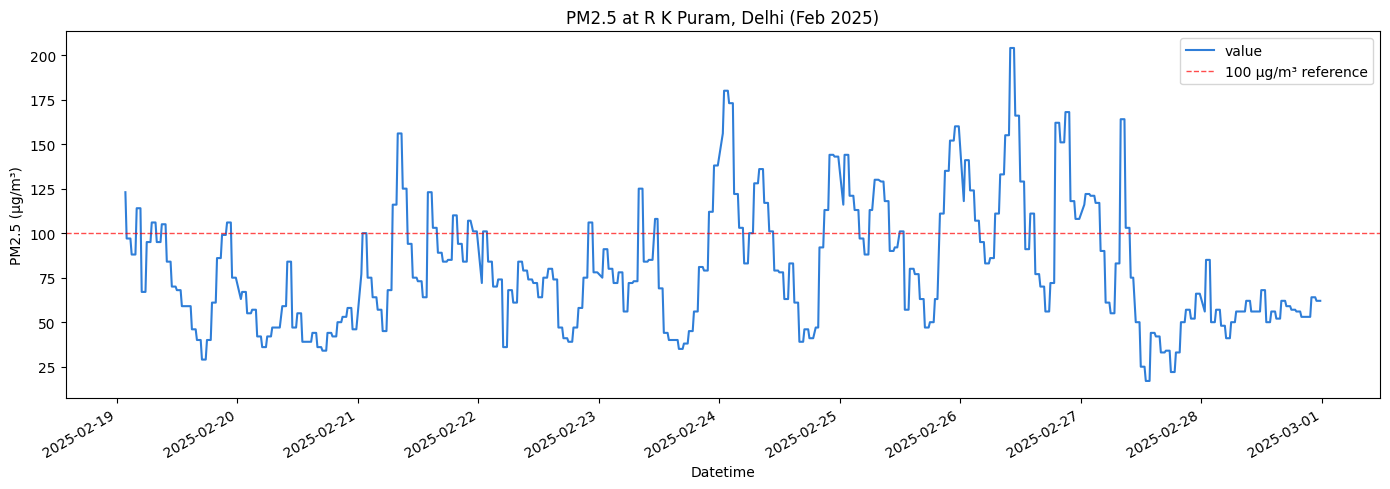


Daily PM2.5 averages:
datetime
2025-02-19 00:00:00+05:30     77.72
2025-02-20 00:00:00+05:30     49.00
2025-02-21 00:00:00+05:30     91.01
2025-02-22 00:00:00+05:30     69.00
2025-02-23 00:00:00+05:30     74.02
2025-02-24 00:00:00+05:30     99.96
2025-02-25 00:00:00+05:30    101.28
2025-02-26 00:00:00+05:30    119.11
2025-02-27 00:00:00+05:30     66.68
2025-02-28 00:00:00+05:30     56.79
Freq: D


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

clean_path = project_root / "data" / "processed" / "station_17_pm25_feb_2025_clean.csv"
df = pd.read_csv(clean_path)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

print("Time series rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())
print("Mean PM2.5:", round(df["value"].mean(), 2), "µg/m³")
print("Max PM2.5:", round(df["value"].max(), 2), "µg/m³")

ax = df["value"].plot(
    figsize=(14, 5),
    linewidth=1.5,
    color="#2f7ed8",
    title="PM2.5 at R K Puram, Delhi (Feb 2025)",
    ylabel="PM2.5 (µg/m³)",
    xlabel="Datetime"
)

ax.axhline(100, color="red", linestyle="--", linewidth=1, alpha=0.7, label="100 µg/m³ reference")
ax.legend()
plt.tight_layout()
plt.show()

# Daily aggregation for an easier read
daily = df["value"].resample("D").mean()
print("\nDaily PM2.5 averages:")
print(daily.round(2).to_string())

## 10. Expanding the same collector to the full usable range

The one-month check proved that the collector works with a real station and a real archive range.

Now we repeat that same process across the full usable window for the same station. This is the point where we stop testing and start building the actual history we need for forecasting.

We are not changing the collector itself. We are only widening the date range from a safe proof-of-concept to the full date span available for this station.


In [2]:
import os
import subprocess
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
output_root = project_root / "data" / "raw" / "openaq"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

env = os.environ.copy()
env["PYTHONPATH"] = str(src_dir)

# Station 17 is the validated working station from the one-month sample.
# We now expand to the full usable archive range for that station.
command = [
    sys.executable,
    "-m",
    "delhi_air.collect_openaq",
    "--start-date", "2025-02-19",
    "--end-date", "2026-09-11",
    "--station", "17",
    "--output-root", str(output_root),
]

print("Running expanded collector for the full usable station range...")
print(" ".join(command))
print()

result = subprocess.run(
    command,
    cwd=str(project_root),
    env=env,
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)

print(f"\nExit code: {result.returncode}")

Running expanded collector for the full usable station range...
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/.venv/bin/python -m delhi_air.collect_openaq --start-date 2025-02-19 --end-date 2026-09-11 --station 17 --output-root /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq

Stations: 1
Date range: 2025-02-19 to 2026-09-11
Files downloaded: 544
Files skipped: 10
Days missing: 16
Total size: 2,473,187 bytes
Elapsed: 79.96 seconds


Exit code: 0


## 11. Verifying the expanded archive

The full-range run should create more raw files, but we still want to confirm the outcome clearly.

We are checking:

- how many files exist now
- whether the archive tree still matches the expected layout
- whether the collection remained idempotent across the full span

In [3]:
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

raw_root = project_root / "data" / "raw" / "openaq"
files = sorted(raw_root.rglob("*.csv.gz"))

print("Raw archive files now:", len(files))
print("First few files:")
for file in files[:5]:
    print(file)

print("\nLast few files:")
for file in files[-5:]:
    print(file)

Raw archive files now: 554
First few files:
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250219.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250220.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250221.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250222.csv.gz
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2025/month=02/location-17-20250223.csv.gz

Last few files:
/Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17/year=2026/month=09/location-17-20260907.csv.gz
/Us